# S2 | Model: Decoder-Only (LM) Experiment

**Session 2** — Compares VLM (full vision-language model) vs LM decoder-only mode
on `vqa_1k_control` under `blind` and `inst_blind` conditions.

In LM mode (`--model_type lm`), the vision encoder is bypassed entirely —
the language backbone receives only the text prompt, no image tokens.
This isolates pure linguistic prior exploitation from any residual image-token influence.

**Conditions:**
- `blind`: blank image (VLM) / no image (LM) — no instruction
- `inst_blind`: + instruction to imagine/use knowledge

**Status:** 9/11 models complete (vicuna-13b + Qwen3-VL-32B pending).


In [1]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter, defaultdict

sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

LM_DIR  = Path('/home/david/Desktop/yuna/HPA/evaluation/logits/lm_decoder/pretrained')
VLM_DIR = Path('/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained')
FIG_DIR = Path('/home/david/Desktop/yuna/HPA/analysis/figures')
FIG_DIR.mkdir(exist_ok=True)

mapper = VQAAnswerMapper()

CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
CT_LABELS     = ['original', 'deictic\nremoved', 'object\nremoved', 'weaker\nobject', 'pronominalized']

CONDITIONS = [
    ('_control_blind',      'blind',      '#e74c3c'),
    ('_control_inst_blind', 'inst_blind', '#3498db'),
]

MODELS = [
    'Qwen3-VL-2B-Instruct', 'Qwen3-VL-4B-Instruct', 'Qwen3-VL-8B-Instruct',
    'InternVL3_5-1B', 'InternVL3_5-2B', 'InternVL3_5-8B',
    'llava-1.5-7b-hf', 'llava-v1.6-mistral-7b-hf', 'llava-v1.6-vicuna-7b-hf',
]

ABSTAIN_TOKENS = ['none','nothing','unknown','unanswerable','no image',
                  'cannot',"can't",'unable','n/a','not visible','not shown']

def load(path):
    p = Path(path)
    if not p.exists(): return None
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()]

def score_rows(rows, ct='question'):
    if not rows: return np.nan
    return np.mean([vqa_accuracy(r['generated_answers'].get(ct,''),
                                  mapper.get_answers(r['question_id'])) for r in rows])

def soft_abstain(rows, ct='question'):
    if not rows: return np.nan
    return np.mean([any(t in r['generated_answers'].get(ct,'').lower() for t in ABSTAIN_TOKENS)
                    for r in rows])

def agreement(lm_rows, vlm_rows, ct='question'):
    vlm_map = {r['question_id']: r['generated_answers'].get(ct,'').lower().strip() for r in vlm_rows}
    return np.mean([r['generated_answers'].get(ct,'').lower().strip() ==
                    vlm_map.get(r['question_id'],'__') for r in lm_rows])

print(f'Models: {len(MODELS)}')
print(f'LM decoder files found: {len(list(LM_DIR.glob("*/*.jsonl")))}')
print(f'VLM files found: {len(list(VLM_DIR.glob("*/*.jsonl")))}')

Models: 9
LM decoder files found: 19
VLM files found: 39


## 1. Accuracy: LM Decoder vs VLM

In [2]:
# Build summary dataframe
rows = []
for model in MODELS:
    for cond_suffix, cond_label, _ in CONDITIONS:
        lm  = load(LM_DIR  / model / f'vqa_1k{cond_suffix}.jsonl')
        vlm = load(VLM_DIR / model / f'vqa_1k{cond_suffix}.jsonl')
        if not lm or not vlm: continue
        rows.append({
            'model':      model,
            'condition':  cond_label,
            'lm_acc':     score_rows(lm),
            'vlm_acc':    score_rows(vlm),
            'lm_abst':    soft_abstain(lm),
            'vlm_abst':   soft_abstain(vlm),
            'agreement':  agreement(lm, vlm),
            'lm_n':       len(lm),
            'vlm_n':      len(vlm),
        })

df = pd.DataFrame(rows)
print(df[['model','condition','lm_acc','vlm_acc','agreement','lm_abst','vlm_abst']]
      .to_string(index=False, float_format='%.3f'))

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...


   ✓ Loaded 214354 VQA annotations


                   model  condition  lm_acc  vlm_acc  agreement  lm_abst  vlm_abst
    Qwen3-VL-2B-Instruct      blind   0.387    0.357      0.401    0.006     0.038
    Qwen3-VL-2B-Instruct inst_blind   0.366    0.356      0.436    0.011     0.028
    Qwen3-VL-4B-Instruct      blind   0.399    0.344      0.467    0.014     0.120
    Qwen3-VL-4B-Instruct inst_blind   0.385    0.371      0.521    0.005     0.041
    Qwen3-VL-8B-Instruct      blind   0.391    0.348      0.436    0.031     0.104
    Qwen3-VL-8B-Instruct inst_blind   0.387    0.372      0.559    0.019     0.037
          InternVL3_5-1B      blind   0.352    0.346      0.481    0.001     0.000
          InternVL3_5-1B inst_blind   0.330    0.312      0.376    0.000     0.005
          InternVL3_5-2B      blind   0.326    0.346      0.317    0.008     0.001
          InternVL3_5-2B inst_blind   0.336    0.341      0.345    0.048     0.005
          InternVL3_5-8B      blind   0.341    0.370      0.377    0.091     0.000
    

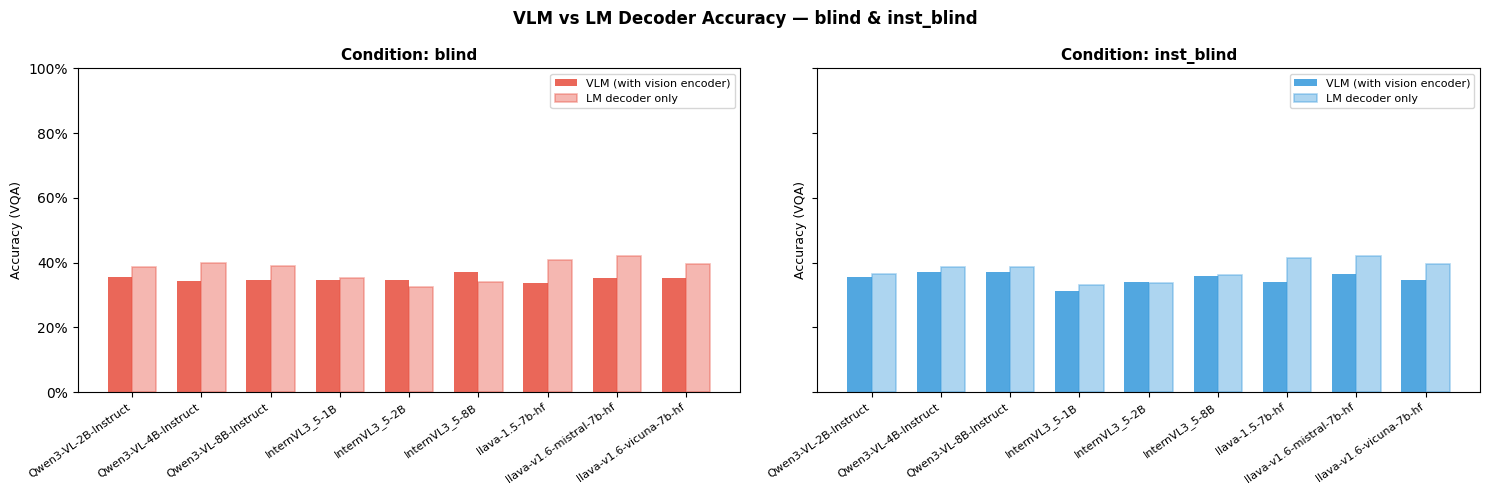

In [3]:
# ── Grouped bar: LM vs VLM accuracy per model × condition ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, (cond_suffix, cond_label, color) in zip(axes, CONDITIONS):
    sub = df[df.condition == cond_label].set_index('model')
    sub = sub.reindex([m for m in MODELS if m in sub.index])
    x = np.arange(len(sub))
    w = 0.35
    ax.bar(x - w/2, sub.vlm_acc, w, label='VLM (with vision encoder)', color=color, alpha=0.85)
    ax.bar(x + w/2, sub.lm_acc,  w, label='LM decoder only',           color=color, alpha=0.4,
           edgecolor=color, linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'Condition: {cond_label}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy (VQA)', fontsize=9)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('VLM vs LM Decoder Accuracy — blind & inst_blind', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lm_decoder_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Answer Agreement: LM Decoder ↔ VLM

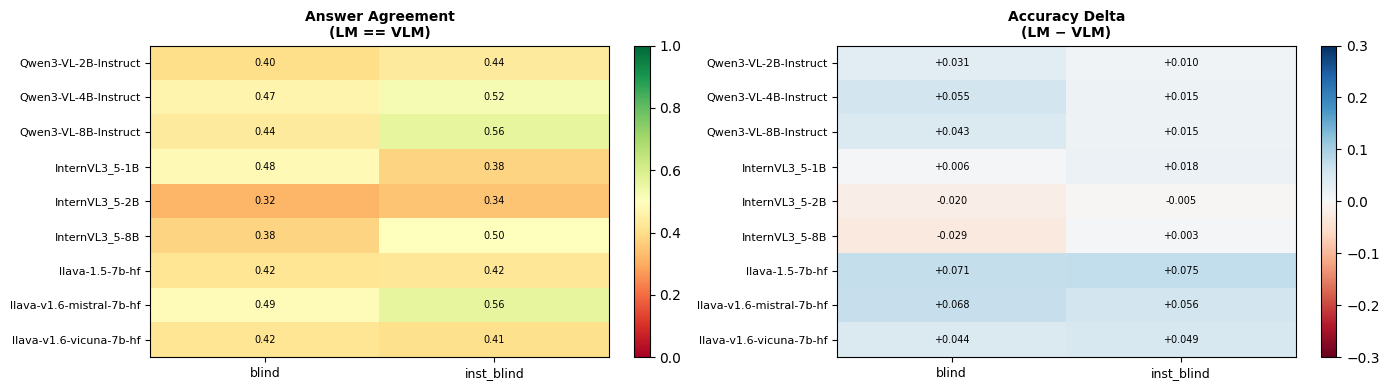

In [4]:
# ── Agreement rate + delta accuracy heatmap ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, title, fmt in [
    (axes[0], 'agreement', 'Answer Agreement\n(LM == VLM)', '.2f'),
    (axes[1], None,        'Accuracy Delta\n(LM − VLM)',   '+.3f'),
]:
    pivot_blind = df[df.condition=='blind'].set_index('model').reindex(MODELS)
    pivot_inst  = df[df.condition=='inst_blind'].set_index('model').reindex(MODELS)

    if metric:
        mat = pd.DataFrame({
            'blind':      pivot_blind[metric],
            'inst_blind': pivot_inst[metric],
        })
        vmin, vmax, cmap = 0, 1, 'RdYlGn'
    else:
        mat = pd.DataFrame({
            'blind':      pivot_blind['lm_acc'] - pivot_blind['vlm_acc'],
            'inst_blind': pivot_inst['lm_acc']  - pivot_inst['vlm_acc'],
        })
        vmin, vmax, cmap = -0.3, 0.3, 'RdBu'

    mat = mat.dropna()
    im = ax.imshow(mat.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_yticks(range(len(mat)))
    ax.set_yticklabels(mat.index, fontsize=8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['blind', 'inst_blind'], fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.04)
    for i in range(len(mat)):
        for j in range(2):
            ax.text(j, i, format(mat.values[i, j], fmt), ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / 'lm_decoder_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Soft Abstention: LM Decoder vs VLM

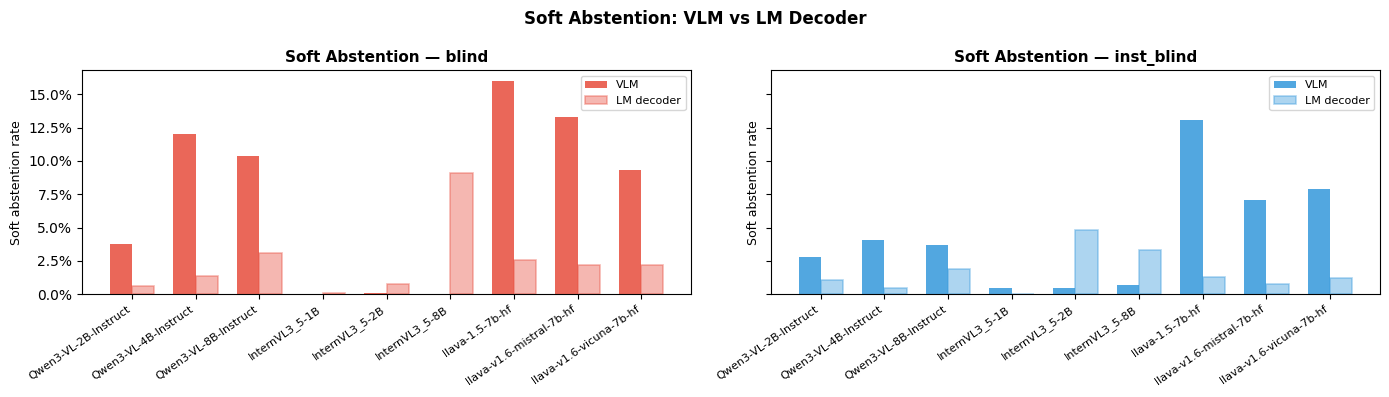

In [5]:
# ── Abstention rates: LM vs VLM, blind vs inst_blind ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, (cond_suffix, cond_label, color) in zip(axes, CONDITIONS):
    sub = df[df.condition == cond_label].set_index('model')
    sub = sub.reindex([m for m in MODELS if m in sub.index])
    x = np.arange(len(sub))
    w = 0.35
    ax.bar(x - w/2, sub.vlm_abst, w, label='VLM', color=color, alpha=0.85)
    ax.bar(x + w/2, sub.lm_abst,  w, label='LM decoder', color=color, alpha=0.4,
           edgecolor=color, linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'Soft Abstention — {cond_label}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Soft abstention rate', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)

plt.suptitle('Soft Abstention: VLM vs LM Decoder', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lm_decoder_abstention.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Degradation Ladder: LM Decoder vs VLM

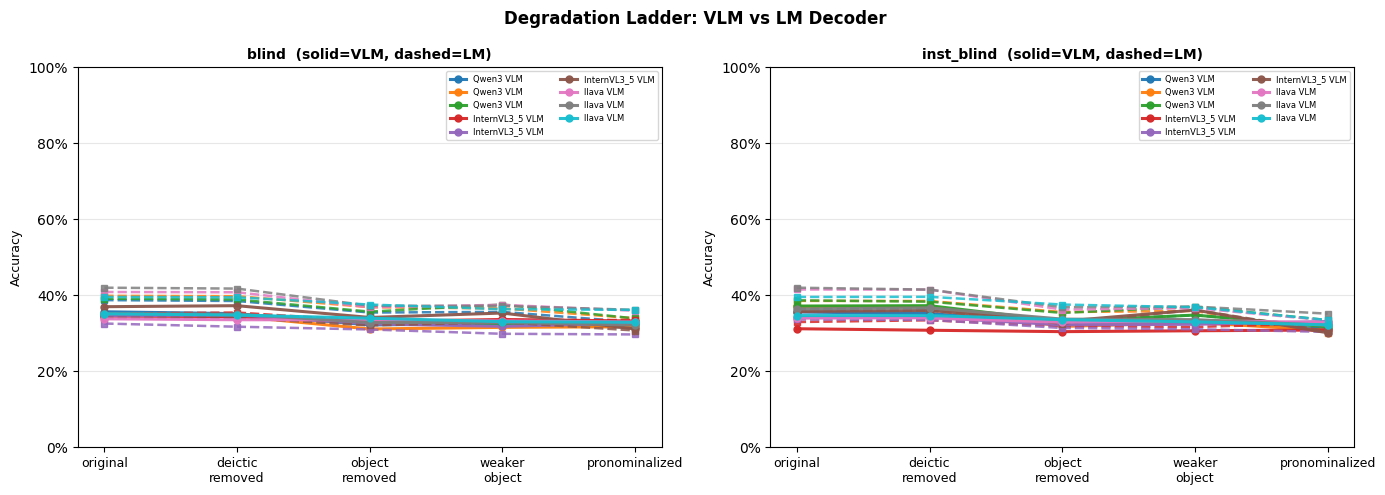

In [6]:
# ── Degradation across 5 control types: LM vs VLM, per condition ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

MODE_STYLE = {
    'vlm': {'ls': '-',  'lw': 2.2, 'marker': 'o', 'alpha': 0.95, 'label_sfx': 'VLM'},
    'lm':  {'ls': '--', 'lw': 1.8, 'marker': 's', 'alpha': 0.85, 'label_sfx': 'LM decoder'},
}

for ax, (cond_suffix, cond_label, base_color) in zip(axes, CONDITIONS):
    model_colors = plt.cm.tab10(np.linspace(0, 0.9, len(MODELS)))

    for model, color in zip(MODELS, model_colors):
        lm  = load(LM_DIR  / model / f'vqa_1k{cond_suffix}.jsonl')
        vlm = load(VLM_DIR / model / f'vqa_1k{cond_suffix}.jsonl')

        for mode, rows in [('vlm', vlm), ('lm', lm)]:
            if not rows: continue
            s = MODE_STYLE[mode]
            accs = [score_rows(rows, ct) for ct in CONTROL_TYPES]
            label = f'{model.split("-")[0]} {s["label_sfx"]}' if mode == 'vlm' else None
            ax.plot(range(len(CONTROL_TYPES)), accs,
                    color=color, ls=s['ls'], lw=s['lw'],
                    marker=s['marker'], markersize=5,
                    alpha=s['alpha'], label=label)

    ax.set_xticks(range(len(CONTROL_TYPES)))
    ax.set_xticklabels(CT_LABELS, fontsize=9)
    ax.set_ylabel('Accuracy', fontsize=9)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f'{cond_label}  (solid=VLM, dashed=LM)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=6, ncol=2, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Degradation Ladder: VLM vs LM Decoder', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lm_decoder_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top Answer Distributions

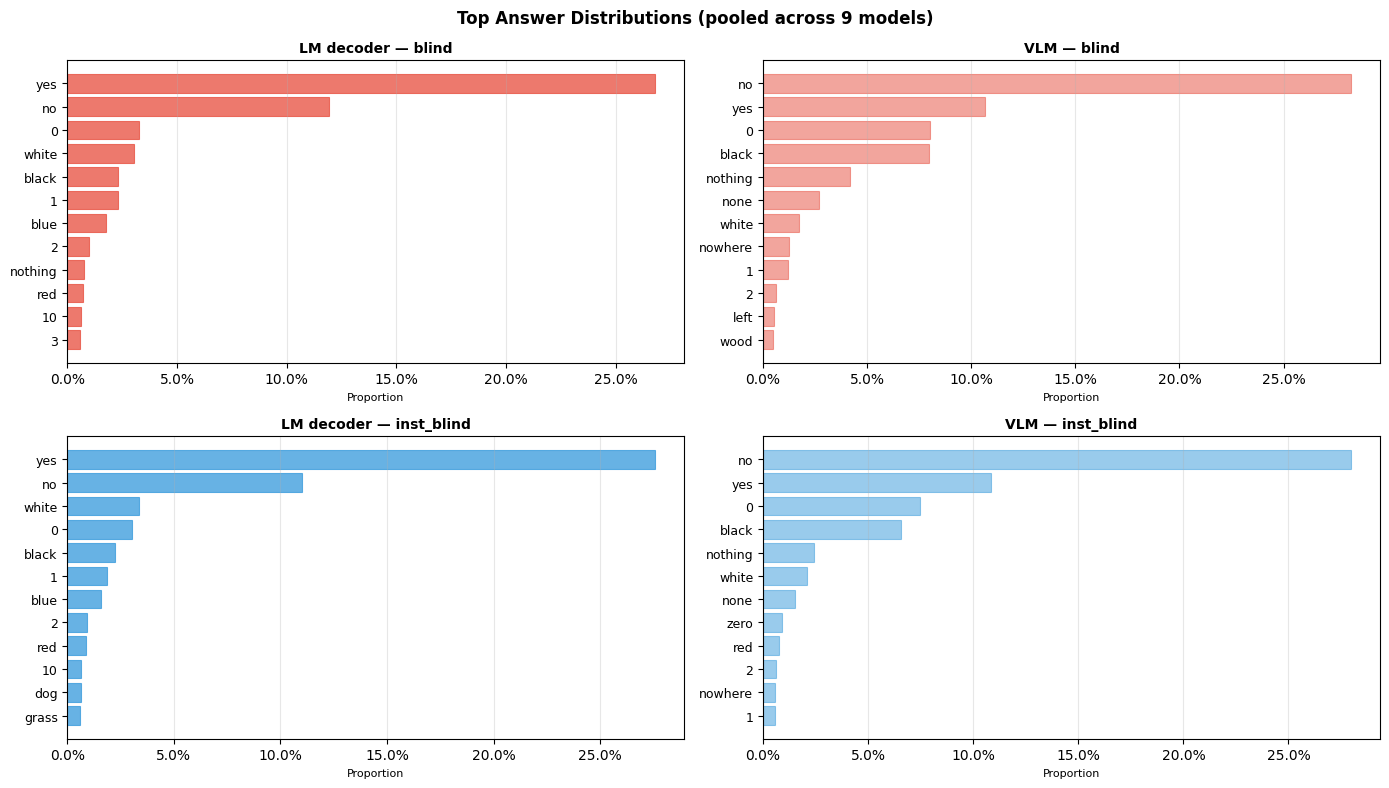

In [7]:
# ── Top-10 answers: LM vs VLM for blind and inst_blind ───────────────────────
# Pooled across all 9 models
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row_idx, (cond_suffix, cond_label, color) in enumerate(CONDITIONS):
    lm_all, vlm_all = [], []
    for model in MODELS:
        lm  = load(LM_DIR  / model / f'vqa_1k{cond_suffix}.jsonl')
        vlm = load(VLM_DIR / model / f'vqa_1k{cond_suffix}.jsonl')
        if lm:  lm_all  += [r['generated_answers'].get('question','').lower().strip() for r in lm]
        if vlm: vlm_all += [r['generated_answers'].get('question','').lower().strip() for r in vlm]

    for col_idx, (answers, title) in enumerate([
        (lm_all,  f'LM decoder — {cond_label}'),
        (vlm_all, f'VLM — {cond_label}'),
    ]):
        ax = axes[row_idx][col_idx]
        top = Counter(answers).most_common(12)
        labels, counts = zip(*top)
        total = len(answers)
        ax.barh(range(len(labels)), [c/total for c in counts],
                color=color, alpha=0.75 if col_idx==0 else 0.5,
                edgecolor=color, linewidth=0.8)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('Proportion', fontsize=8)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top Answer Distributions (pooled across 9 models)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lm_decoder_top_answers.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Inst_Blind Effect: Blind → Inst_Blind Shift

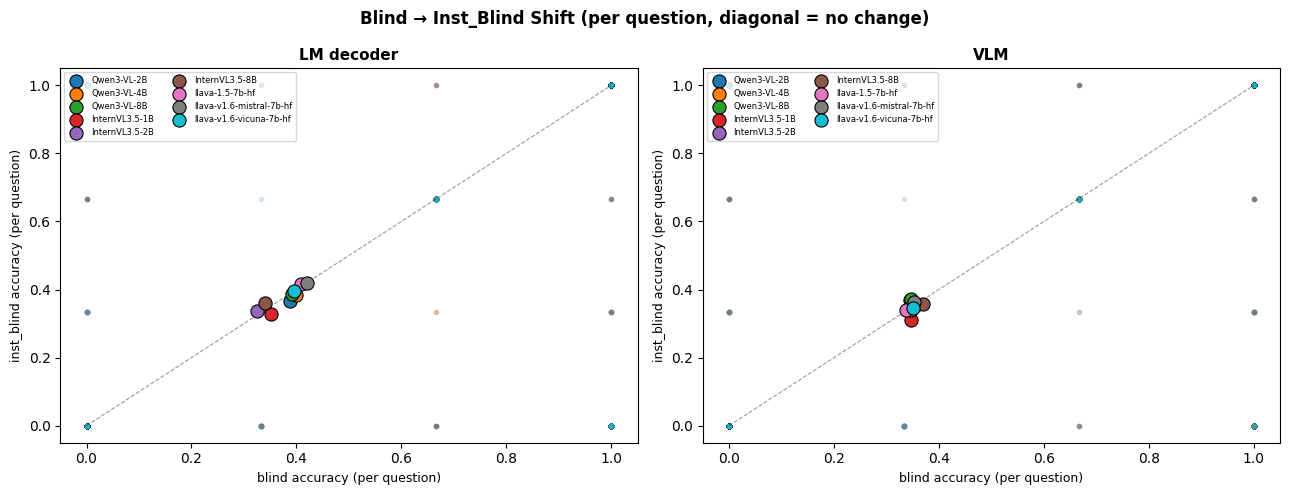

In [8]:
# ── Scatter: blind acc vs inst_blind acc, LM vs VLM, per model ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mode, dir_ in [(axes[0], 'LM decoder', LM_DIR), (axes[1], 'VLM', VLM_DIR)]:
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(MODELS)))
    for model, color in zip(MODELS, colors):
        blind_rows = load(dir_ / model / 'vqa_1k_control_blind.jsonl')
        inst_rows  = load(dir_ / model / 'vqa_1k_control_inst_blind.jsonl')
        if not blind_rows or not inst_rows: continue

        # Per-question accuracy
        b_acc = {r['question_id']: vqa_accuracy(r['generated_answers'].get('question',''),
                                                  mapper.get_answers(r['question_id']))
                 for r in blind_rows}
        i_acc = {r['question_id']: vqa_accuracy(r['generated_answers'].get('question',''),
                                                  mapper.get_answers(r['question_id']))
                 for r in inst_rows}
        qids = list(set(b_acc) & set(i_acc))
        bv = [b_acc[q] for q in qids]
        iv = [i_acc[q] for q in qids]
        short = model.replace('-Instruct','').replace('3_5','3.5')
        ax.scatter(bv, iv, color=color, alpha=0.08, s=8)
        # Model-level means as large marker
        ax.scatter(np.mean(bv), np.mean(iv), color=color, s=90,
                   edgecolors='k', linewidths=0.8, zorder=5, label=short)

    ax.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.4)
    ax.set_xlabel('blind accuracy (per question)', fontsize=9)
    ax.set_ylabel('inst_blind accuracy (per question)', fontsize=9)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{mode}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=6, ncol=2, loc='upper left')

plt.suptitle('Blind → Inst_Blind Shift (per question, diagonal = no change)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lm_decoder_blind_vs_inst.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Table

In [9]:
# ── Summary table: LM vs VLM per model + condition ───────────────────────────
summary = df.copy()
summary['acc_delta'] = (summary['lm_acc'] - summary['vlm_acc']).round(3)
summary['lm_acc']    = summary['lm_acc'].round(3)
summary['vlm_acc']   = summary['vlm_acc'].round(3)
summary['agreement'] = summary['agreement'].round(3)
summary['lm_abst']   = summary['lm_abst'].round(3)
summary['vlm_abst']  = summary['vlm_abst'].round(3)

print(summary[['model','condition','vlm_acc','lm_acc','acc_delta','agreement','lm_abst','vlm_abst']]
      .sort_values(['condition','model'])
      .to_string(index=False))

print()
print('=== Averages ===')
print(summary.groupby('condition')[['vlm_acc','lm_acc','acc_delta','agreement','lm_abst','vlm_abst']]
      .mean().round(3))

                   model  condition  vlm_acc  lm_acc  acc_delta  agreement  lm_abst  vlm_abst
          InternVL3_5-1B      blind    0.346   0.352      0.006      0.481    0.001     0.000
          InternVL3_5-2B      blind    0.346   0.326     -0.020      0.317    0.008     0.001
          InternVL3_5-8B      blind    0.370   0.341     -0.029      0.377    0.091     0.000
    Qwen3-VL-2B-Instruct      blind    0.357   0.387      0.031      0.401    0.006     0.038
    Qwen3-VL-4B-Instruct      blind    0.344   0.399      0.055      0.467    0.014     0.120
    Qwen3-VL-8B-Instruct      blind    0.348   0.391      0.043      0.436    0.031     0.104
         llava-1.5-7b-hf      blind    0.338   0.409      0.071      0.420    0.026     0.160
llava-v1.6-mistral-7b-hf      blind    0.352   0.420      0.068      0.490    0.022     0.133
 llava-v1.6-vicuna-7b-hf      blind    0.351   0.396      0.044      0.421    0.022     0.093
          InternVL3_5-1B inst_blind    0.312   0.330      0.